# Baseline Models — Dummy Classifier & Logistic Regression

Objetivo: estabelecer metricas de referencia (piso minimo) antes da modelagem com MLP.
Todos os experimentos sao logados no MLflow para rastreabilidade.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    ConfusionMatrixDisplay,
)

# Semente global para reprodutibilidade
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [2]:
# Carregando o dataset original
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

# --- Reaplicando a limpeza do EDA ---
# Convertendo Total Charges para float e removendo os 11 registros problemáticos
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df = df.dropna(subset=["Total Charges"]).reset_index(drop=True)

# Removendo colunas desnecessárias (identificadores, leakage, sem variância)
cols_to_drop = [
    "Count", "Country", "State", "CustomerID", "Lat Long",
    "Latitude", "Longitude", "Zip Code", "City",
    "Churn Score", "CLTV", "Churn Reason", "Churn Label",
]
df = df.drop(columns=cols_to_drop)

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['Churn Value'].mean():.2%}")


Shape: (7032, 20)
Churn rate: 26.58%


## Pipeline de Pre-processamento

In [3]:
# Separando features do target
X = df.drop(columns=["Churn Value"])
y = df["Churn Value"]

# Identificando colunas por tipo
numeric_features = ["Tenure Months", "Monthly Charges", "Total Charges"]
categorical_features = [col for col in X.columns if col not in numeric_features]

print(f"Features numéricas ({len(numeric_features)}): {numeric_features}")
print(f"Features categóricas ({len(categorical_features)}): {categorical_features}")

# Split treino/teste — estratificado para manter a proporção de churn em ambos os sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y,  # garante ~26.5% de churn em treino e teste
)

print(f"\nTreino: {X_train.shape} | Churn rate: {y_train.mean():.2%}")
print(f"Teste:  {X_test.shape}  | Churn rate: {y_test.mean():.2%}")


Features numéricas (3): ['Tenure Months', 'Monthly Charges', 'Total Charges']
Features categóricas (16): ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Treino: (5625, 19) | Churn rate: 26.58%
Teste:  (1407, 19)  | Churn rate: 26.58%


In [4]:
# Pré-processador: escala numéricas e codifica categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)


## Experimento 1 — Dummy Classifier

2026/03/20 12:48:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/20 12:48:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


ROC-AUC : 0.5000
F1-Score: 0.0000

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.73      1.00      0.85      1033
       Churn       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407



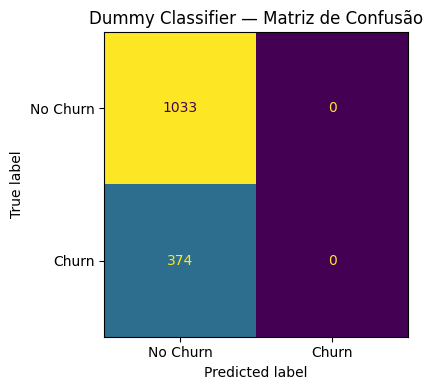

In [5]:
# Configurando o experimento — todas as runs ficam agrupadas aqui no MLflow UI
mlflow.set_experiment("telco-churn-baseline")

with mlflow.start_run(run_name="dummy-classifier"):

    # --- Modelo ---
    dummy_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)),
    ])

    dummy_pipeline.fit(X_train, y_train)
    y_pred  = dummy_pipeline.predict(X_test)
    y_proba = dummy_pipeline.predict_proba(X_test)[:, 1]

    # --- Métricas ---
    roc_auc = roc_auc_score(y_test, y_proba)
    f1      = f1_score(y_test, y_pred)

    # --- Log no MLflow ---
    mlflow.log_param("strategy", "most_frequent")
    mlflow.log_param("random_seed", RANDOM_SEED)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("f1_score", f1)
    mlflow.sklearn.log_model(dummy_pipeline, artifact_path="model")

    # --- Exibição ---
    print(f"ROC-AUC : {roc_auc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

    # Matriz de confusão
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["No Churn", "Churn"],
        colorbar=False,
        ax=ax,
    )
    ax.set_title("Dummy Classifier — Matriz de Confusão")
    plt.tight_layout()
    mlflow.log_figure(fig, "confusion_matrix.png")
    plt.show()


## Experimento 2 — Regressao Logistica

2026/03/20 12:48:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/20 12:48:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


ROC-AUC : 0.8425
F1-Score: 0.6068

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



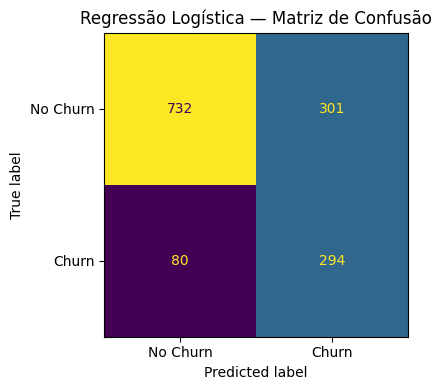

In [6]:
with mlflow.start_run(run_name="logistic-regression"):

    # --- Modelo ---
    lr_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",  # corrige desbalanceamento
            max_iter=1000,            # garante convergência
            random_state=RANDOM_SEED,
            C=1.0,                    # regularização L2 padrão (1/lambda)
        )),
    ])

    lr_pipeline.fit(X_train, y_train)
    y_pred  = lr_pipeline.predict(X_test)
    y_proba = lr_pipeline.predict_proba(X_test)[:, 1]

    # --- Métricas ---
    roc_auc = roc_auc_score(y_test, y_proba)
    f1      = f1_score(y_test, y_pred)

    # --- Log no MLflow ---
    mlflow.log_param("C", 1.0)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("random_seed", RANDOM_SEED)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("f1_score", f1)
    mlflow.sklearn.log_model(lr_pipeline, artifact_path="model")

    # --- Exibição ---
    print(f"ROC-AUC : {roc_auc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

    # Matriz de confusão
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["No Churn", "Churn"],
        colorbar=False,
        ax=ax,
    )
    ax.set_title("Regressão Logística — Matriz de Confusão")
    plt.tight_layout()
    mlflow.log_figure(fig, "confusion_matrix.png")
    plt.show()


## Exportando o Dataset Pre-processado

O dataframe limpo (apos remocao de colunas e correcao de tipos, mas **sem encoding**) e salvo em
`data/processed/` para reuso no proximo notebook de engenharia de modelos.
Exportar antes do encoding preserva a legibilidade das colunas e permite aplicar
feature engineering no proximo notebook antes de encodar.

In [7]:
import os

# Salvando o dataframe limpo (sem encoding) para reuso no notebook de engenharia de modelos
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/telco_churn_cleaned.csv", index=False)

print("Dataset pre-processado salvo em: data/processed/telco_churn_cleaned.csv")
print(f"Shape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")

Dataset pre-processado salvo em: data/processed/telco_churn_cleaned.csv
Shape: (7032, 20)
Colunas: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']


## Comparacao Final — Baseline Models

| Modelo | ROC-AUC | F1-Score (Churn) | Observacao |
|--------|---------|-----------------|------------|
| Dummy Classifier | ~0.50 | ~0.00 | Piso minimo — preve sempre "No Churn" |
| Logistic Regression | 0.8425 | 0.6068 | Benchmark linear a ser superado |

**Meta para os proximos estagios:** ROC-AUC > 0.85 e F1 > 0.65

**Artefatos exportados:**
- `data/processed/telco_churn_cleaned.csv` — dataset limpo sem encoding (input para `03_model_engineering.ipynb`)
- MLflow experiment `telco-churn-baseline` — runs: `dummy-classifier`, `logistic-regression`